# Librerías

In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

import os
import pandas as pd
from pandas.plotting import scatter_matrix
import numpy as np 
from pathlib import Path
from typing import Callable, List
from scipy.stats import norm # For calculating the PDF
from scipy.stats import gaussian_kde

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "end_to_end_project"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

#def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
#    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
#    print("Saving figure", fig_id)
#    if tight_layout:
#        plt.tight_layout()
#    plt.savefig(path, format=fig_extension, dpi=resolution)
import tarfile
import urllib.request
import math
import statistics as stat

In [2]:
f = "datasets/housing/housing_data.csv" 
housing = pd.read_csv(f)

# Teorema Central del limite (Limit Central Theorem)

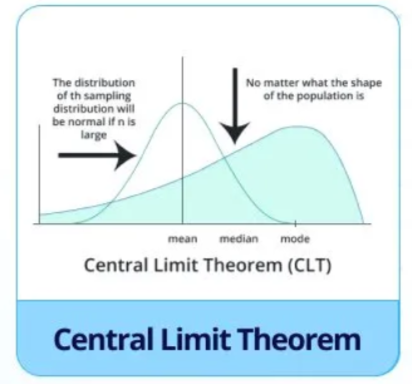

### Teorema del Límite Central (CLT)

Sea 
$\{X_1, X_2, ..., X_n\}$
una muestra aleatoria de una población con media $\mu$ y varianza $\sigma^2$.

Entonces, cuando $n$ es suficientemente grande, la distribución de la media muestral:

$
\bar{X}_n = \frac{1}{n} \sum_{i=1}^{n} X_i
$

se aproxima a una distribución normal:

$
\bar{X}_n \sim \mathcal{N} \left( \mu, \frac{\sigma^2}{n} \right)
$

independientemente de la distribución original de los $X_i$.


### Intervalo de Confianza con t de Student

Cuando la desviación estándar poblacional $\sigma$ es desconocida, y la muestra es pequeña, usamos la distribución t:

$
\bar{x} \pm t_{\alpha/2,\,n-1} \cdot \frac{s}{\sqrt{n}}
$

donde:

- $\bar{x}$ = media muestral  
- $s$ = desviación estándar muestral  
- $n$ = tamaño de la muestra  
- $t_{\alpha/2,\,n-1}$ = valor crítico de t con n-1 grados de libertad


## Funciones

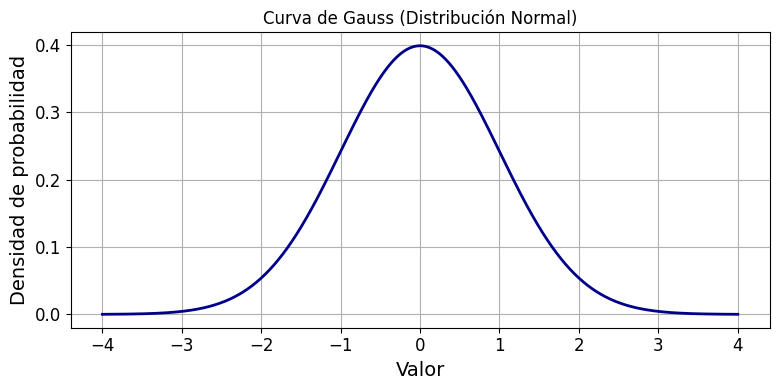

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Datos para una curva de Gauss
x = np.linspace(-4, 4, 1000)
mu = 0      # media
sigma = 1   # desviación estándar
y = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# Graficar la curva
plt.figure(figsize=(8, 4))
plt.plot(x, y, color='darkblue', linewidth=2)
plt.title('Curva de Gauss (Distribución Normal)')
plt.xlabel('Valor')
plt.ylabel('Densidad de probabilidad')
plt.grid(True)
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
from typing import Callable, List

def muestrear_columna(df: pd.DataFrame, columna: str, porcentaje: float, replace: bool = True) -> pd.Series:
    """
    Realiza un muestreo aleatorio sobre una columna específica de un DataFrame de pandas.

    Parámetros:
    - df (pd.DataFrame): DataFrame de entrada.
    - columna (str): Nombre de la columna a muestrear.
    - porcentaje (float): Porcentaje de elementos a tomar, expresado como decimal (ej. 0.1 para 10%).
    - replace (bool): Si True, se realiza con reemplazo. Si False, sin reemplazo.

    Retorna:
    - pd.Series: Serie con los elementos muestreados.
    
    Requiere:
    - pandas importado como pd.
    """
    if columna not in df.columns:
        raise ValueError(f"La columna '{columna}' no existe en el DataFrame.")

    total_filas = len(df)
    muestra_n = int(total_filas * porcentaje)

    if not replace and muestra_n > total_filas:
        raise ValueError("No se puede tomar una muestra sin reemplazo mayor al total de filas.")
    return df[columna].sample(n=muestra_n, replace=replace).reset_index(drop=True)
    # random_state=42 se usa para que la muestra siempre sea la misma, si no se usa siempre será distinta aleatoreamente.


def simular_promedios_muestrales(
    df: pd.DataFrame,
    columna: str,
    porcentaje: float,
    repeticiones: int,
    funcion_muestreo: Callable[[pd.DataFrame, str, float, bool], pd.Series],
    replace: bool = True
) -> List[float]:
    """
    Simula el Teorema Central del Límite repitiendo un muestreo aleatorio varias veces
    y calculando el promedio de cada muestra.

    Parámetros:
    - df (pd.DataFrame): DataFrame de entrada.
    - columna (str): Nombre de la columna a muestrear.
    - porcentaje (float): Porcentaje de la población a tomar en cada muestra (ej. 0.1 para 10%).
    - repeticiones (int): Número de repeticiones del experimento.
    - funcion_muestreo (Callable): Función de muestreo que retorna una Serie (como `muestrear_columna`).
    - replace (bool): Define si se usa muestreo con reemplazo.
    
    Retorna:
    - List[float]: Lista con los promedios de cada muestra.
    """
    promedios = []
    for _ in range(repeticiones):
        muestra = funcion_muestreo(df, columna, porcentaje, replace)
        promedio = muestra.mean()
        promedios.append(promedio)
    return promedios


In [5]:
def comp_bells_hist(data_comp, 
                    range_to_graph: int = 1000, 
                    figsize: tuple = (10, 6),
                    real_data_label: str = "Datos_Reales_KDE",
                    color_real: str = "blue",
                    gaus_ideal_label: str = "Gauss_Bell_ideal", 
                    color_ideal: str = "red",
                    linewidth: int = 2, 
                    linestyle: str = '--',
                    title: str = "Compare Real Data - Norm Dist",
                    xlabel: str = "Values",
                    ylabel: str = "PDF",
                    show_hist: bool = True,
                    bins: int = 30,
                    hist_color: str = "gray",
                    hist_alpha: float = 0.4,
                    hist_label: str = "Histograma"
                    ):
    """
    Compara visualmente una curva KDE (estimación empírica de densidad), la campana 
    de Gauss teórica (calculada desde la media y desviación estándar), y opcionalmente el histograma.

    Parámetros
    ----------
    data_comp : array-like
        Datos numéricos sobre los que se desea construir la comparación.

    range_to_graph : int, opcional
        Número de puntos equidistantes para generar las curvas. Mayor valor produce curvas más suaves.

    figsize : tuple, opcional
        Dimensiones del gráfico (ancho, alto) en pulgadas.

    real_data_label : str, opcional
        Etiqueta para la curva KDE empírica.

    color_real : str, opcional
        Color para la curva KDE.

    gaus_ideal_label : str, opcional
        Etiqueta para la curva normal teórica.

    color_ideal : str, opcional
        Color de la curva normal teórica.

    linewidth : int, opcional
        Grosor de las curvas.

    linestyle : str, opcional
        Estilo de línea para la curva gaussiana.

    title : str, opcional
        Título del gráfico.

    xlabel : str, opcional
        Etiqueta del eje X.

    ylabel : str, opcional
        Etiqueta del eje Y.

    show_hist : bool, opcional
        Si True, se muestra también el histograma de los datos.

    bins : int, opcional
        Número de divisiones (barras) del histograma.

    hist_color : str, opcional
        Color de las barras del histograma.

    hist_alpha : float, opcional
        Opacidad del histograma (entre 0 y 1).

    hist_label : str, opcional
        Etiqueta para el histograma en la leyenda.

    Retorna
    -------
    None
        Muestra el gráfico combinado con Matplotlib.
    """
    
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import gaussian_kde

    # Convertir los datos a array
    datos_array = np.array(data_comp)

    # Media y desviación estándar
    mu = np.mean(datos_array)
    sigma = np.std(datos_array)

    # Rango X para KDE (limitado a los datos)
    x_kde = np.linspace(min(datos_array), max(datos_array), range_to_graph)

    # Rango X para Gauss (centrado en la media)
    x_gauss = np.linspace(mu - 4*sigma, mu + 4*sigma, range_to_graph)

    # KDE empírica
    kde = gaussian_kde(datos_array)
    y_kde = kde(x_kde)

    # Gauss teórica
    prefactor = 1 / (sigma * np.sqrt(2 * np.pi))
    exponente = np.exp(- (x_gauss - mu)**2 / (2 * sigma**2))
    y_gauss = prefactor * exponente

    # Crear gráfico
    plt.figure(figsize=figsize)

    # Histograma opcional
    if show_hist:
        plt.hist(datos_array, bins=bins, density=True, 
                 alpha=hist_alpha, color=hist_color, edgecolor='black',
                 label=hist_label)

    # Curva KDE
    plt.plot(x_kde, y_kde, color=color_real, label=real_data_label, linewidth=linewidth)

    # Curva Gauss
    plt.plot(x_gauss, y_gauss, color=color_ideal, linestyle=linestyle, 
             label=gaus_ideal_label, linewidth=linewidth)

    # Estética del gráfico
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()


In [6]:
def comp_bells(data_comp, 
               range_to_graph: int = 1000, 
               figsize: tuple = (10, 6),
               real_data_label: str = "Datos_Reales_KDE",
               color_real: str = "blue",
               gaus_ideal_label: str = "Gauss_Bell_ideal", 
               color_ideal: str = "red",
               linewidth: int = 2, 
               linestyle: str = '--',
               title: str = "Compare Real Data - Norm Dist",
               xlabel: str = "Values",
               ylabel: str = "PDF",
               ):
    """
    Compara visualmente una curva KDE (estimación empírica de densidad) con la campana 
    de Gauss teórica generada a partir de los datos proporcionados.

    Parámetros
    ----------
    data_comp : array-like
        Lista o arreglo con los datos numéricos sobre los que se quiere hacer la comparación.
        Se espera que provengan de un muestreo, por ejemplo, bajo el Teorema del Límite Central.
    
    range_to_graph : int, opcional (por defecto=1000)
        Número de puntos para interpolar la curva en el eje X. A mayor valor, mayor suavidad.
    
    figsize : tuple, opcional (por defecto=(10, 6))
        Tamaño del gráfico (ancho, alto) en pulgadas.
    
    real_data_label : str, opcional
        Etiqueta para la curva KDE empírica.
    
    color_real : str, opcional
        Color de la curva KDE empírica.
    
    gaus_ideal_label : str, opcional
        Etiqueta para la campana de Gauss teórica.
    
    color_ideal : str, opcional
        Color de la curva normal teórica.
    
    linewidth : int, opcional
        Grosor de ambas líneas (KDE y Gauss).
    
    linestyle : str, opcional
        Estilo de línea para la curva de Gauss (e.g., '--' para línea punteada).
    
    title : str, opcional
        Título del gráfico.
    
    xlabel : str, opcional
        Etiqueta del eje X.
    
    ylabel : str, opcional
        Etiqueta del eje Y.

    Retorna
    -------
    None
        Muestra un gráfico comparativo entre la distribución empírica (KDE) y la normal teórica.
    """
    
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import gaussian_kde

    # Convertir los datos a un array de NumPy
    datos_array = np.array(data_comp)
    
    # Calcular media y desviación estándar de los datos
    mu = np.mean(datos_array)
    sigma = np.std(datos_array)
    
    # 1. Rango para KDE (basado en los datos reales)
    x_kde = np.linspace(min(datos_array), max(datos_array), range_to_graph)

    # 2. Rango para campana de Gauss (más amplio y centrado en la media)
    x_gauss = np.linspace(mu - 4*sigma, mu + 4*sigma, range_to_graph)
    
    # Calcular KDE empírica
    kde = gaussian_kde(datos_array)
    y_kde = kde(x_kde)
    
    # Calcular Gauss manualmente sobre su propio rango
    prefactor = 1 / (sigma * np.sqrt(2 * np.pi))
    exponente = np.exp(- (x_gauss - mu)**2 / (2 * sigma**2))
    y_gauss = prefactor * exponente

    # Crear gráfico
    plt.figure(figsize=figsize)

    # Dibujar KDE
    plt.plot(x_kde, y_kde, color=color_real, label=real_data_label, linewidth=linewidth)

    # Dibujar Gauss
    plt.plot(x_gauss, y_gauss, color=color_ideal, linestyle=linestyle, label=gaus_ideal_label, linewidth=linewidth)

    # Personalización
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()

## Variables y rectificación de los datos.

In [7]:
col = "median_house_value"
filtered_df = housing[~housing[col].isin([350000, 450000, 225000, 275000, 500000, 500001])]

In [8]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [9]:
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19375 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           19375 non-null  float64
 1   latitude            19375 non-null  float64
 2   housing_median_age  19375 non-null  float64
 3   total_rooms         19375 non-null  float64
 4   total_bedrooms      19176 non-null  float64
 5   population          19375 non-null  float64
 6   households          19375 non-null  float64
 7   median_income       19375 non-null  float64
 8   median_house_value  19375 non-null  float64
 9   ocean_proximity     19375 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [10]:
datos0 = []
for _ in range(1000):
    a = muestrear_columna(df=filtered_df, 
                          columna=col, 
                          porcentaje=.2, 
                          replace=False)
    datos0.append(a.mean())

In [11]:
datos_array = np.array(datos0)
media = np.mean(datos_array)
desviacion = np.std(datos_array)
x = np.linspace(media - 3*desviacion, media + 3*desviacion, 1000)
y = norm.pdf(x, loc=media, scale=desviacion)

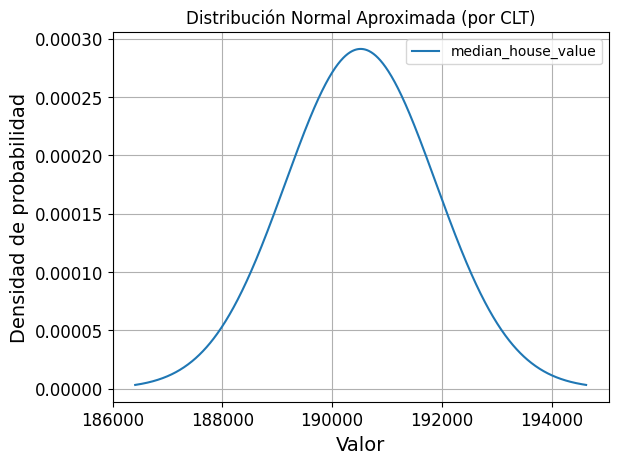

In [12]:
plt.plot(x, y, label=col)
plt.title('Distribución Normal Aproximada (por CLT)')
plt.xlabel('Valor')
plt.ylabel('Densidad de probabilidad')
plt.grid(True)
plt.legend()
plt.show()

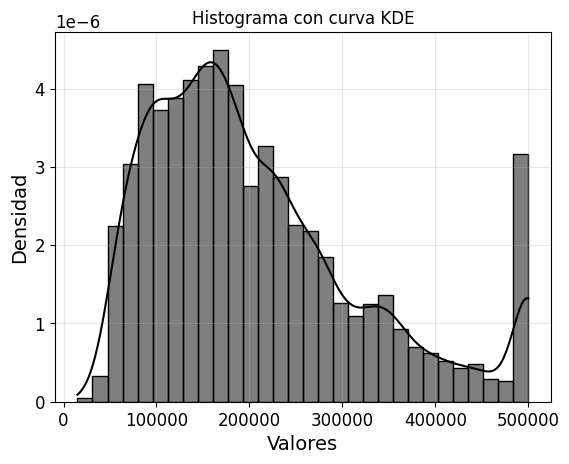

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suponiendo que tus datos están en un array o serie llamada `datos`
# datos = np.array([...])  # reemplaza esto con tus datos reales
datos1 = housing[col]
sns.histplot(datos1, kde=True, stat="density", bins=30, color="#000000", edgecolor='black')
plt.title("Histograma con curva KDE")
plt.xlabel("Valores")
plt.ylabel("Densidad")
plt.grid(alpha=0.3)
plt.show()

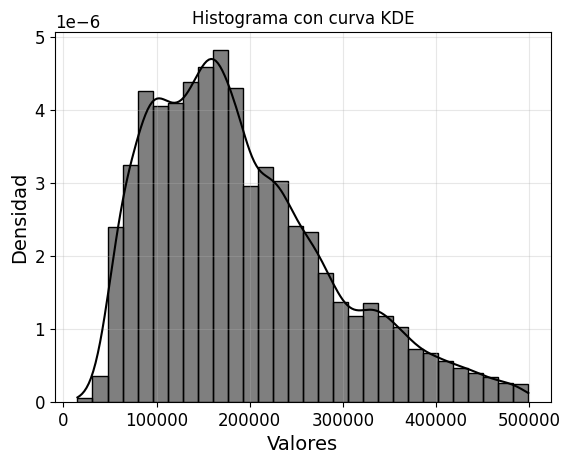

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suponiendo que tus datos están en un array o serie llamada `datos`
# datos = np.array([...])  # reemplaza esto con tus datos reales
datos2 = filtered_df[col]
sns.histplot(datos2, kde=True, stat="density", bins=30, color="#000000", edgecolor='black')
plt.title("Histograma con curva KDE")
plt.xlabel("Valores")
plt.ylabel("Densidad")
plt.grid(alpha=0.3)
plt.show()

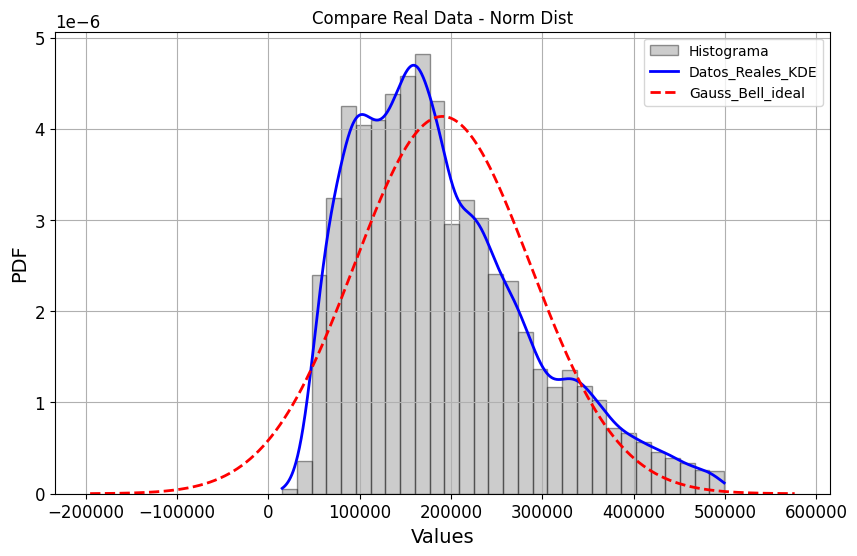

In [15]:
comp_bells_hist(filtered_df[col])

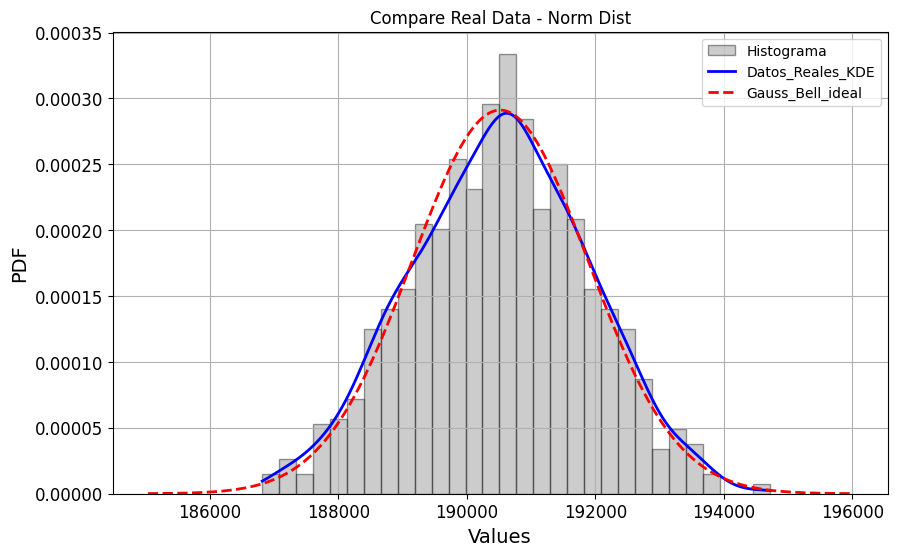

In [16]:
comp_bells_hist(datos0)

# Confidence interval

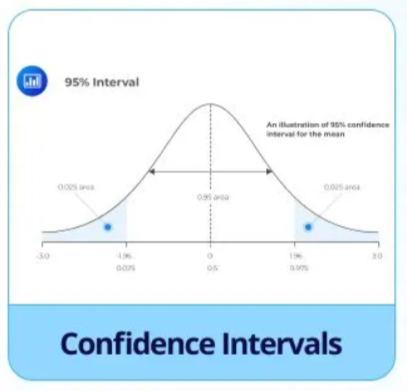

Supón que quieres controlar la calidad de tornillos producidos. Tomas una muestra de 100 tornillos y encuentras que su longitud media es de 50 mm con una desviación estándar de 2 mm.

Quieres un intervalo de confianza del 95% para estimar la longitud media verdadera de todos los tornillos.

Tamaño de muestra: $n$ = 100

Media muestral: $\bar{x}$ = 50 mm

Desviación estándar ($\sigma$): 2 mm

Error estándar:

$SE = \frac{\sigma}{\sqrt{n}} = \frac{2}{\sqrt{100}} = 0.2$

Valor $Z$ para 95%: 1.96

IC 95%:

$50 \pm (1.96 \cdot 0.2) = 50\pm 0.392\Rightarrow [49.608,50.392]$

**Interpretación:**
Estás 95% confiado de que la media verdadera de todos los tornillos producidos está entre 49.608 mm y 50.392 mm.

In [17]:
IC_data = datos0.copy()

In [21]:
n = len(IC_data)
mean = np.mean(IC_data)
stdv = np.std(IC_data)

In [22]:
SE = stdv / np.sqrt(n)

In [23]:
Z = 1.96

In [24]:
SE_left = mean - (Z * SE)
SE_right = mean + (Z * SE)

In [31]:
SE_left

np.float64(190434.80353980145)

In [32]:
SE_right

np.float64(190604.6588798114)

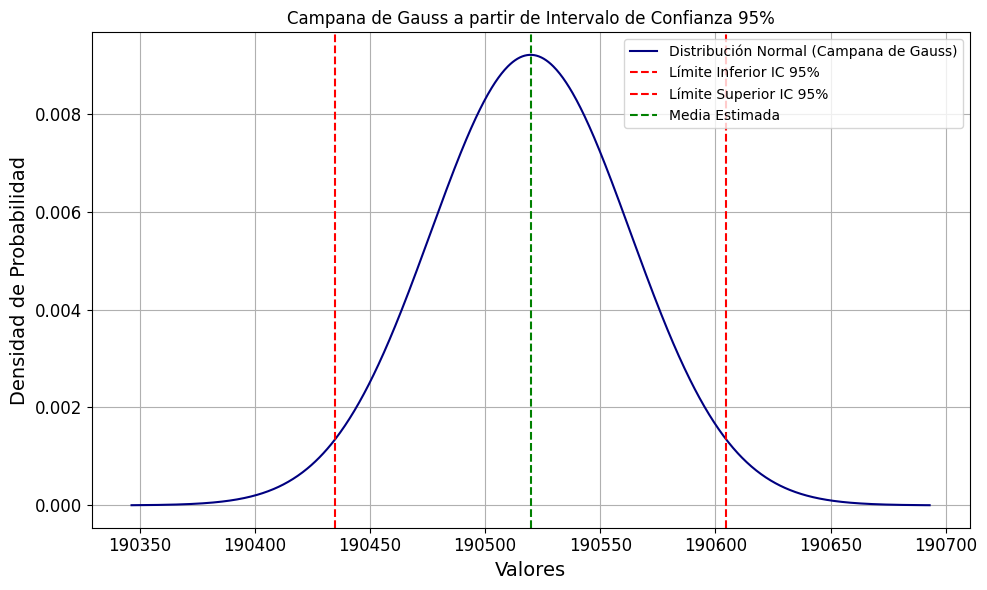

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- 1. Datos del intervalo de confianza (IC al 95%) ---
lim_inf = SE_left  # Límite inferior
lim_sup = SE_right  # Límite superior

# --- 2. Calcular la media y el error estándar ---
media = (lim_inf + lim_sup) / 2
margen_error = (lim_sup - lim_inf) / 2
error_estandar = margen_error / 1.96  # Asumiendo z = 1.96

# --- 3. Crear valores de x para graficar la curva ---
x = np.linspace(media - 4*error_estandar, media + 4*error_estandar, 1000)
y = norm.pdf(x, loc=media, scale=error_estandar)

# --- 4. Graficar ---
plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Distribución Normal (Campana de Gauss)', color='navy')
plt.axvline(lim_inf, color='red', linestyle='--', label='Límite Inferior IC 95%')
plt.axvline(lim_sup, color='red', linestyle='--', label='Límite Superior IC 95%')
plt.axvline(media, color='green', linestyle='--', label='Media Estimada')

plt.title('Campana de Gauss a partir de Intervalo de Confianza 95%')
plt.xlabel('Valores')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


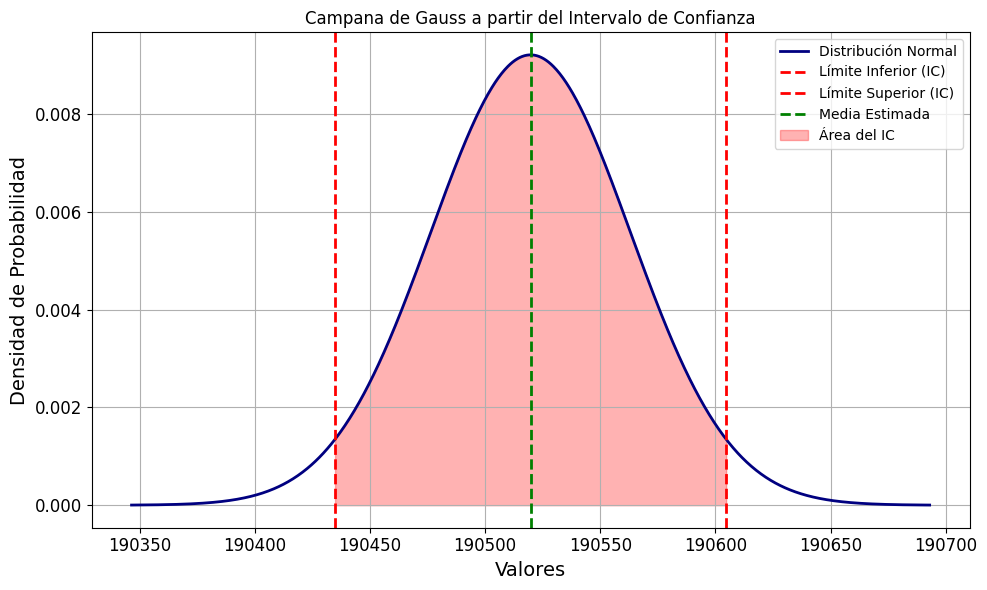

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def plot_gaussian_from_ci(
    lim_inf: float,
    lim_sup: float,
    intervalo: int = 4,
    z: float = 1.96,
    figsize: tuple = (10, 6),
    color_curva: str = 'navy',
    color_ic: str = 'red',
    color_media: str = 'green',
    linewidth: int = 2,
    linestyle_ic: str = '--',
    titulo: str = 'Campana de Gauss a partir del Intervalo de Confianza',
    xlabel: str = 'Valores',
    ylabel: str = 'Densidad de Probabilidad',
    grid: bool = True,
    sombrear_area: bool = False
):
    """
    Grafica una curva de distribución normal (campana de Gauss) utilizando solo los
    límites inferior y superior de un intervalo de confianza.

    Parámetros
    ----------
    lim_inf : float
        Límite inferior del intervalo de confianza.
    lim_sup : float
        Límite superior del intervalo de confianza.
    intervalo : int, opcional
        Rango de desviaciones estándar para graficar (por defecto 4 sigmas a cada lado).
    z : float, opcional
        Valor z usado para construir el intervalo de confianza (por defecto 1.96 para IC al 95%).
    figsize : tuple, opcional
        Tamaño de la figura.
    color_curva : str, opcional
        Color de la curva normal.
    color_ic : str, opcional
        Color de las líneas verticales del IC.
    color_media : str, opcional
        Color de la línea vertical de la media.
    linewidth : int, opcional
        Grosor de las líneas.
    linestyle_ic : str, opcional
        Estilo de las líneas del IC.
    titulo : str, opcional
        Título del gráfico.
    xlabel : str, opcional
        Etiqueta del eje X.
    ylabel : str, opcional
        Etiqueta del eje Y.
    grid : bool, opcional
        Mostrar cuadrícula.
    sombrear_area : bool, opcional
        Si True, sombrea el área del IC bajo la curva.
    """

    # Calcular media y error estándar
    media = (lim_inf + lim_sup) / 2
    margen_error = (lim_sup - lim_inf) / 2
    error_estandar = margen_error / z

    # Crear valores x para la curva
    x = np.linspace(media - intervalo * error_estandar, media + intervalo * error_estandar, 1000)
    y = norm.pdf(x, loc=media, scale=error_estandar)

    # Iniciar gráfico
    plt.figure(figsize=figsize)
    plt.plot(x, y, color=color_curva, linewidth=linewidth, label='Distribución Normal')

    # Líneas verticales
    plt.axvline(lim_inf, color=color_ic, linestyle=linestyle_ic, linewidth=linewidth, label=f'Límite Inferior (IC)')
    plt.axvline(lim_sup, color=color_ic, linestyle=linestyle_ic, linewidth=linewidth, label=f'Límite Superior (IC)')
    plt.axvline(media, color=color_media, linestyle='--', linewidth=linewidth, label='Media Estimada')

    # Sombrado del área del IC
    if sombrear_area:
        x_fill = np.linspace(lim_inf, lim_sup, 500)
        y_fill = norm.pdf(x_fill, loc=media, scale=error_estandar)
        plt.fill_between(x_fill, y_fill, color=color_ic, alpha=0.3, label='Área del IC')

    # Personalización
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    if grid:
        plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_gaussian_from_ci(SE_left, SE_right, sombrear_area=True)

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def plot_gaussian_from_ci(
    lim_inf: float,
    lim_sup: float,
    intervalo: int = 4,
    z: float = 1.96,
    figsize: tuple = (10, 6),
    color_curva: str = 'navy',
    color_ic: str = 'red',
    color_media: str = 'green',
    linewidth: int = 2,
    linestyle_ic: str = '--',
    titulo: str = 'Campana de Gauss a partir del Intervalo de Confianza',
    xlabel: str = 'Valores',
    ylabel: str = 'Densidad de Probabilidad',
    grid: bool = True,
    sombrear_area: bool = False,
    mostrar_valores: bool = True,
    decimales: int = 2
):
    """
    Grafica una curva de distribución normal usando solo los límites del intervalo de confianza (IC).

    Parámetros principales
    ----------------------
    lim_inf : float
        Límite inferior del intervalo de confianza.
    lim_sup : float
        Límite superior del intervalo de confianza.
    intervalo : int, opcional
        Rango de desviaciones estándar para graficar (por defecto 4).
    z : float, opcional
        Valor z usado para calcular el error estándar (por defecto 1.96).
    sombrear_area : bool, opcional
        Si True, sombrea el área bajo la curva entre los límites del IC.
    mostrar_valores : bool, opcional
        Si True, muestra los valores de los límites al lado de las líneas rojas.
    decimales : int, opcional
        Número de decimales que se muestran en las etiquetas.

    Otros parámetros
    ----------------
    figsize, color_curva, color_ic, color_media, linewidth, linestyle_ic,
    titulo, xlabel, ylabel, grid: personalización del gráfico.
    """

    # Calcular media y error estándar
    media = (lim_inf + lim_sup) / 2
    margen_error = (lim_sup - lim_inf) / 2
    error_estandar = margen_error / z

    # Crear valores para la curva
    x = np.linspace(media - intervalo * error_estandar, media + intervalo * error_estandar, 1000)
    y = norm.pdf(x, loc=media, scale=error_estandar)

    # Iniciar gráfico
    plt.figure(figsize=figsize)
    plt.plot(x, y, color=color_curva, linewidth=linewidth, label='Distribución Normal')

    # Líneas verticales: límites del IC y media
    plt.axvline(lim_inf, color=color_ic, linestyle=linestyle_ic, linewidth=linewidth)
    plt.axvline(lim_sup, color=color_ic, linestyle=linestyle_ic, linewidth=linewidth)
    plt.axvline(media, color=color_media, linestyle='--', linewidth=linewidth, label='Media Estimada')

    # Mostrar valores de límites
    if mostrar_valores:
        ymax = max(y)
        plt.text(lim_inf, ymax * 0.05, f'{lim_inf:.{decimales}f}', color=color_ic, ha='right', va='bottom')
        plt.text(lim_sup, ymax * 0.05, f'{lim_sup:.{decimales}f}', color=color_ic, ha='left', va='bottom')

    # Sombrear área del IC
    if sombrear_area:
        x_fill = np.linspace(lim_inf, lim_sup, 500)
        y_fill = norm.pdf(x_fill, loc=media, scale=error_estandar)
        plt.fill_between(x_fill, y_fill, color=color_ic, alpha=0.3, label='Área del IC')

    # Personalización
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    if grid:
        plt.grid(True)
    plt.tight_layout()
    plt.show()


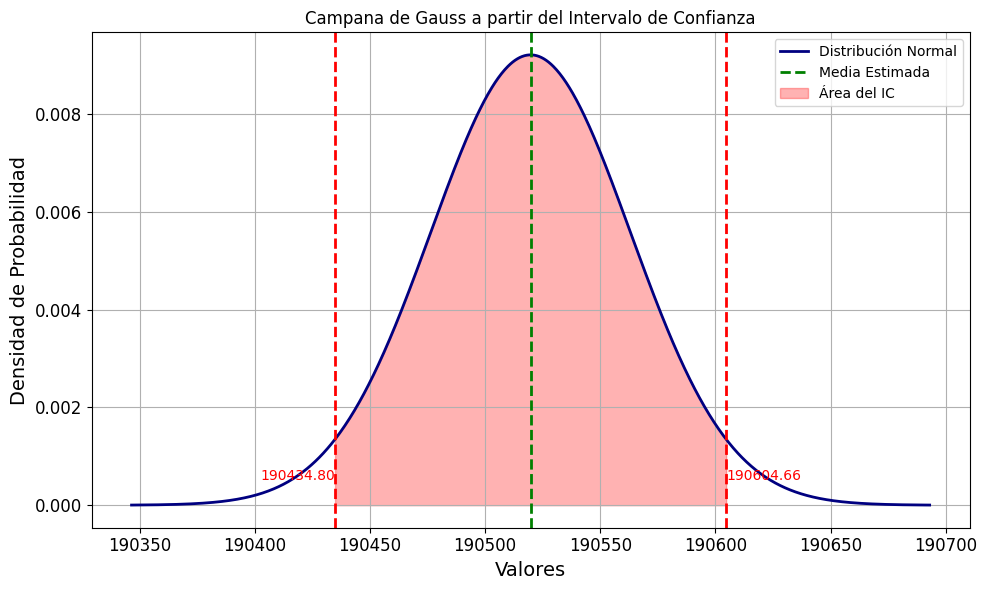

In [42]:
plot_gaussian_from_ci(
    lim_inf=SE_left,
    lim_sup=SE_right,
    intervalo=4,
    z=1.96,
    sombrear_area=True,
    mostrar_valores=True
)


In [ ]:
# Hypothesis Testing

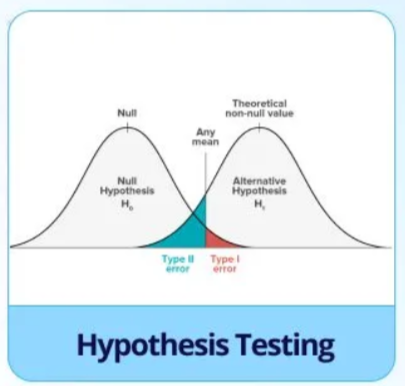

In [43]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt


In [44]:
# Supongamos que esta es nuestra muestra tras aplicar el tratamiento
# Generamos datos con media 118 y desviación estándar 4
np.random.seed(1)  # reproducibilidad
sample = np.random.normal(loc=118, scale=4, size=25)

# Visualizamos la media muestral
print("Media de la muestra:", np.mean(sample))


Media de la muestra: 117.94908044994737


3. Formular las hipótesis


$H_0: \mu = 120 \rightarrow$ El medicamento no tiene efecto


$H_1: \mu < 120 \rightarrow$ El medicamento reduce la presión


Este es un test unilateral (cola izquierda).

In [45]:
# Media bajo H0
mu_0 = 120

# Prueba t de una muestra
t_stat, p_value = stats.ttest_1samp(sample, popmean=mu_0)

# Como es prueba de una sola cola (H1: mu < mu0), dividimos el valor p
one_tailed_p = p_value / 2

print("Estadístico t:", t_stat)
print("Valor p (una cola):", one_tailed_p)


Estadístico t: -2.334541922005291
Valor p (una cola): 0.014131605115838879


In [46]:
alpha = 0.05

if one_tailed_p < alpha:
    print("Se rechaza H₀: el medicamento reduce la presión arterial.")
else:
    print("No hay evidencia suficiente para rechazar H₀.")


Se rechaza H₀: el medicamento reduce la presión arterial.


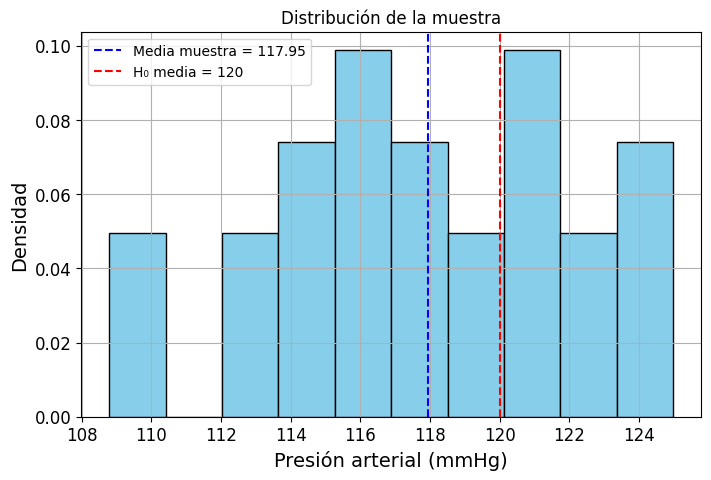

In [47]:
# Histograma de la muestra
plt.figure(figsize=(8, 5))
plt.hist(sample, bins=10, color="skyblue", edgecolor="black", density=True)
plt.axvline(np.mean(sample), color="blue", linestyle="--", label=f"Media muestra = {np.mean(sample):.2f}")
plt.axvline(mu_0, color="red", linestyle="--", label=f"H₀ media = {mu_0}")
plt.title("Distribución de la muestra")
plt.xlabel("Presión arterial (mmHg)")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True)
plt.show()


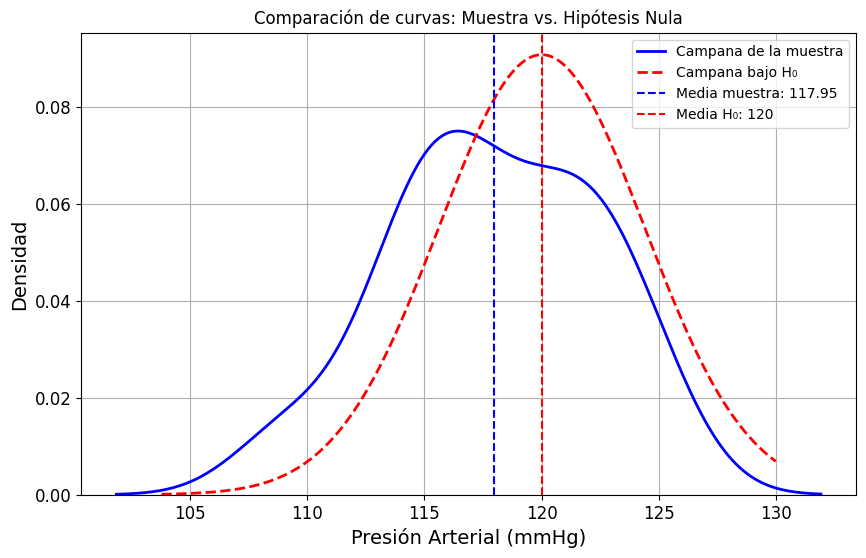

In [48]:
import seaborn as sns
from scipy.stats import norm

# Parámetros conocidos o asumidos
mu_0 = 120
std_0 = np.std(sample, ddof=1)

# Crear gráfico
plt.figure(figsize=(10, 6))

# KDE de la muestra (estimación empírica)
sns.kdeplot(sample, label="Campana de la muestra", linewidth=2, color='blue')

# Campana de Gauss bajo H0
x = np.linspace(min(sample)-5, max(sample)+5, 500)
plt.plot(x, norm.pdf(x, loc=mu_0, scale=std_0), 
         label="Campana bajo H₀", linestyle='--', color='red', linewidth=2)

# Líneas verticales
plt.axvline(np.mean(sample), color='blue', linestyle='--', label=f"Media muestra: {np.mean(sample):.2f}")
plt.axvline(mu_0, color='red', linestyle='--', label=f"Media H₀: {mu_0}")

# Etiquetas
plt.title("Comparación de curvas: Muestra vs. Hipótesis Nula")
plt.xlabel("Presión Arterial (mmHg)")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True)
plt.show()


In [53]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

def plot_hypothesis_test_B(sample: np.ndarray,
                          mu_h0: float,
                          title: str = "Comparación entre muestra y H₀",
                          kde_label: str = "Curva de la muestra",
                          h0_label: str = "Curva bajo H₀",
                          figsize: tuple = (10, 6),
                          color_kde: str = "blue",
                          color_h0: str = "red",
                          linewidth: int = 2,
                          linestyle_h0: str = "--") -> None:
    """
    Grafica la curva de densidad de una muestra y la compara con una curva normal bajo H₀.

    Parámetros
    ----------
    sample : np.ndarray
        Datos numéricos de la muestra.
    mu_h0 : float
        Valor hipotético de la media bajo H₀.
    title : str
        Título del gráfico.
    kde_label : str
        Etiqueta para la curva KDE de la muestra.
    h0_label : str
        Etiqueta para la curva teórica bajo H₀.
    figsize : tuple
        Tamaño de la figura (ancho, alto).
    color_kde : str
        Color de la curva KDE.
    color_h0 : str
        Color de la curva bajo H₀.
    linewidth : int
        Grosor de las líneas.
    linestyle_h0 : str
        Estilo de línea para la curva de H₀.
    """
    std_sample = np.std(sample, ddof=1)
    mu_sample = np.mean(sample)

    # Rango para el eje x
    x_range = np.linspace(mu_sample - 4*std_sample, mu_sample + 4*std_sample, 500)

    # Crear gráfico
    plt.figure(figsize=figsize)

    # KDE empírica de la muestra
    sns.kdeplot(sample, label=kde_label, linewidth=linewidth, color=color_kde)

    # Curva teórica bajo H₀
    plt.plot(x_range, norm.pdf(x_range, loc=mu_h0, scale=std_sample),
             label=h0_label, linestyle=linestyle_h0, color=color_h0, linewidth=linewidth)

    # Líneas verticales
    plt.axvline(mu_sample, color=color_kde, linestyle='--', label=f"Media muestra: {mu_sample:.2f}")
    plt.axvline(mu_h0, color=color_h0, linestyle='--', label=f"Media H₀: {mu_h0}")

    # Detalles del gráfico
    plt.title(title)
    plt.xlabel("Valores")
    plt.ylabel("Densidad")
    plt.legend()
    plt.grid(True)
    plt.show()


In [54]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, ttest_1samp

def plot_hypothesis_test_A(sample: np.ndarray,
                          mu_h0: float,
                          alpha: float = 0.05,
                          title: str = "Comparación entre muestra y H₀",
                          kde_label: str = "Curva de la muestra",
                          h0_label: str = "Curva bajo H₀",
                          figsize: tuple = (10, 6),
                          color_kde: str = "blue",
                          color_h0: str = "red",
                          linewidth: int = 2,
                          linestyle_h0: str = "--") -> None:
    """
    Realiza una prueba t de una muestra, grafica la curva KDE y la distribución teórica bajo H₀,
    e imprime los resultados estadísticos con interpretación.

    Parámetros
    ----------
    sample : np.ndarray
        Datos numéricos de la muestra.
    mu_h0 : float
        Valor hipotético de la media bajo H₀.
    alpha : float
        Nivel de significancia para la decisión.
    title : str
        Título del gráfico.
    kde_label : str
        Etiqueta para la curva KDE de la muestra.
    h0_label : str
        Etiqueta para la curva teórica bajo H₀.
    figsize : tuple
        Tamaño de la figura (ancho, alto).
    color_kde : str
        Color de la curva KDE.
    color_h0 : str
        Color de la curva bajo H₀.
    linewidth : int
        Grosor de las líneas.
    linestyle_h0 : str
        Estilo de línea para la curva de H₀.
    """
    # Estadísticas básicas
    mu_sample = np.mean(sample)
    std_sample = np.std(sample, ddof=1)

    # Prueba t de una muestra
    t_stat, p_value_two_tailed = ttest_1samp(sample, popmean=mu_h0)
    p_value_one_tailed = p_value_two_tailed / 2

    # Resultado textual
    print(f"Media de la muestra: {mu_sample:.4f}")
    print(f"Estadístico t: {t_stat:.4f}")
    print(f"Valor p (una cola): {p_value_one_tailed:.4f}")
    print(f"Nivel de significancia α = {alpha}")

    if p_value_one_tailed < alpha and t_stat < 0:
        print("Se rechaza H₀: hay evidencia de que la media muestral es menor que la media bajo H₀.")
    else:
        print("No hay evidencia suficiente para rechazar H₀.")

    # Gráfico
    x_range = np.linspace(mu_sample - 4*std_sample, mu_sample + 4*std_sample, 500)

    plt.figure(figsize=figsize)
    sns.kdeplot(sample, label=kde_label, linewidth=linewidth, color=color_kde)
    plt.plot(x_range, norm.pdf(x_range, loc=mu_h0, scale=std_sample),
             label=h0_label, linestyle=linestyle_h0, color=color_h0, linewidth=linewidth)

    # Líneas verticales con anotaciones
    plt.axvline(mu_sample, color=color_kde, linestyle='--', label=f"Media muestra: {mu_sample:.2f}")
    plt.axvline(mu_h0, color=color_h0, linestyle='--', label=f"Media H₀: {mu_h0}")

    plt.title(title)
    plt.xlabel("Valores")
    plt.ylabel("Densidad")
    plt.legend()
    plt.grid(True)
    plt.show()


Media de la muestra: 117.9491
Estadístico t: -2.3345
Valor p (una cola): 0.0141
Nivel de significancia α = 0.05
Se rechaza H₀: hay evidencia de que la media muestral es menor que la media bajo H₀.


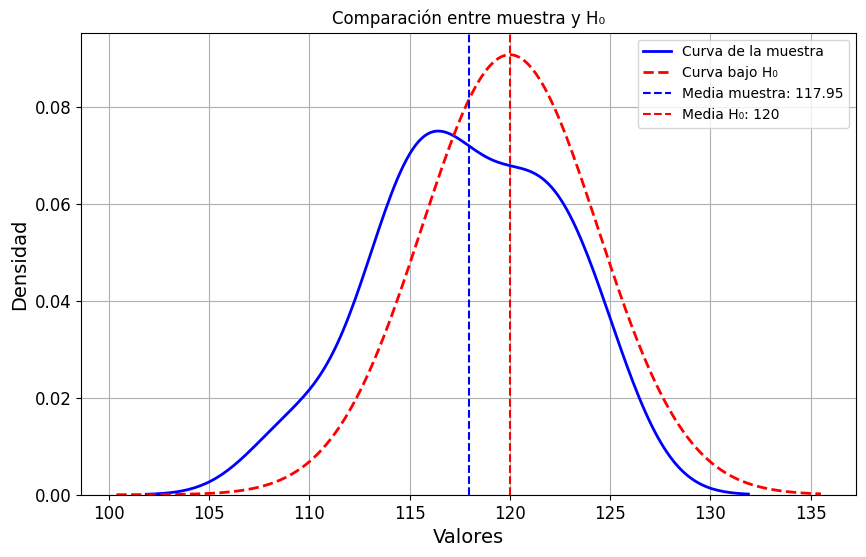

In [58]:
# Supongamos que esta es tu muestra
np.random.seed(1)
sample = np.random.normal(loc=118, scale=4, size=25)

# Llamamos a la función
plot_hypothesis_test_A(sample, mu_h0=120)


In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_1samp, f_oneway, chi2_contingency, norm

def run_hypothesis_test_C(data,
                        test_type: str,
                        mu_h0: float = None,
                        alpha: float = 0.05,
                        title: str = "Visualización de la prueba de hipótesis") -> None:
    """
    Ejecuta una prueba de hipótesis ('t', 'anova', 'chi2') e imprime los resultados con visualización correspondiente.

    Parámetros
    ----------
    data : array-like, list, dict, DataFrame o tabla
        Datos de entrada para la prueba.
    test_type : str
        Tipo de prueba a realizar: 't', 'anova', 'chi2'.
    mu_h0 : float, opcional
        Valor de referencia bajo H₀ (solo para t-test).
    alpha : float
        Nivel de significancia para la decisión.
    title : str
        Título del gráfico (si aplica).

    Salida
    ------
    Imprime resultados estadísticos e incluye visualización apropiada por tipo de prueba.
    """
    try:
        if test_type == 't':
            # Validación
            if mu_h0 is None:
                raise ValueError("Debe proporcionar mu_h0 para realizar un t-test.")

            sample = np.asarray(data)
            if sample.ndim != 1:
                raise ValueError("El t-test solo admite datos unidimensionales.")

            mu_sample = np.mean(sample)
            std_sample = np.std(sample, ddof=1)
            t_stat, p_two = ttest_1samp(sample, popmean=mu_h0)
            p_one = p_two / 2

            # Resultados
            print("[T-Test]")
            print(f"Media de la muestra: {mu_sample:.4f}")
            print(f"Estadístico t: {t_stat:.4f}")
            print(f"Valor p (una cola): {p_one:.4f}")
            print(f"Nivel de significancia α = {alpha}")
            if p_one < alpha and t_stat < 0:
                print("Se rechaza H₀: evidencia de que la media muestral < mu₀.")
            else:
                print("No hay evidencia suficiente para rechazar H₀.")

            # Gráfico KDE + Gauss
            x = np.linspace(mu_sample - 4 * std_sample, mu_sample + 4 * std_sample, 500)
            plt.figure(figsize=(10, 6))
            sns.kdeplot(sample, label="Curva de la muestra", color='blue', linewidth=2)
            plt.plot(x, norm.pdf(x, mu_h0, std_sample), label="Curva bajo H₀", linestyle='--', color='red')
            plt.axvline(mu_sample, color='blue', linestyle='--', label=f"Media muestra: {mu_sample:.2f}")
            plt.axvline(mu_h0, color='red', linestyle='--', label=f"Media H₀: {mu_h0}")
            plt.title(title)
            plt.xlabel("Valores")
            plt.ylabel("Densidad")
            plt.legend()
            plt.grid(True)
            plt.show()

        elif test_type == 'anova':
            # Extraer grupos
            if isinstance(data, dict):
                df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data.items()]))
            elif isinstance(data, pd.DataFrame):
                df = data.copy()
            else:
                raise ValueError("Para ANOVA, use un dict o un DataFrame con columnas como grupos.")

            groups = [df[col].dropna().values for col in df.columns]
            f_stat, p_value = f_oneway(*groups)

            print("[ANOVA]")
            print(f"Estadístico F: {f_stat:.4f}")
            print(f"Valor p: {p_value:.4f}")
            print(f"Nivel de significancia α = {alpha}")
            if p_value < alpha:
                print("Se rechaza H₀: hay diferencias significativas entre al menos dos grupos.")
            else:
                print("No hay evidencia de diferencias entre los grupos.")

            # Boxplot
            df_melt = df.melt(var_name="Grupo", value_name="Valores")
            plt.figure(figsize=(10, 6))
            #sns.boxplot(x="Grupo", y="Valores", data=df_melt, palette="pastel")
            #sns.boxplot(x="Grupo", y="Valores", data=df_melt, palette="pastel")
            sns.boxplot(x="Grupo", y="Valores", data=df_melt, hue="Grupo", palette="pastel")

            plt.title(title)
            plt.grid(True)
            plt.show()

        elif test_type == 'chi2':
            table = np.array(data)
            if table.ndim != 2:
                raise ValueError("Para chi², se requiere una tabla bidimensional.")

            chi2, p_value, dof, expected = chi2_contingency(table)

            print("[Chi-Cuadrado]")
            print(f"Chi² = {chi2:.4f}, p = {p_value:.4f}, grados de libertad = {dof}")
            print(f"Nivel de significancia α = {alpha}")
            if p_value < alpha:
                print("Se rechaza H₀: las variables son dependientes.")
            else:
                print("No hay evidencia suficiente para rechazar H₀ (independencia).")

            # Heatmap de frecuencias observadas
            plt.figure(figsize=(8, 6))
            sns.heatmap(table, annot=True, cmap="Blues", fmt="d")
            plt.title("Frecuencias observadas (Chi²)")
            plt.xlabel("Categoría columna")
            plt.ylabel("Categoría fila")
            plt.show()

        else:
            raise ValueError("Tipo de prueba no reconocido. Usa 't', 'anova' o 'chi2'.")

    except Exception as e:
        print(f"Error: {e}")


[T-Test]
Media de la muestra: 117.9491
Estadístico t: -2.3345
Valor p (una cola): 0.0141
Nivel de significancia α = 0.05
Se rechaza H₀: evidencia de que la media muestral < mu₀.


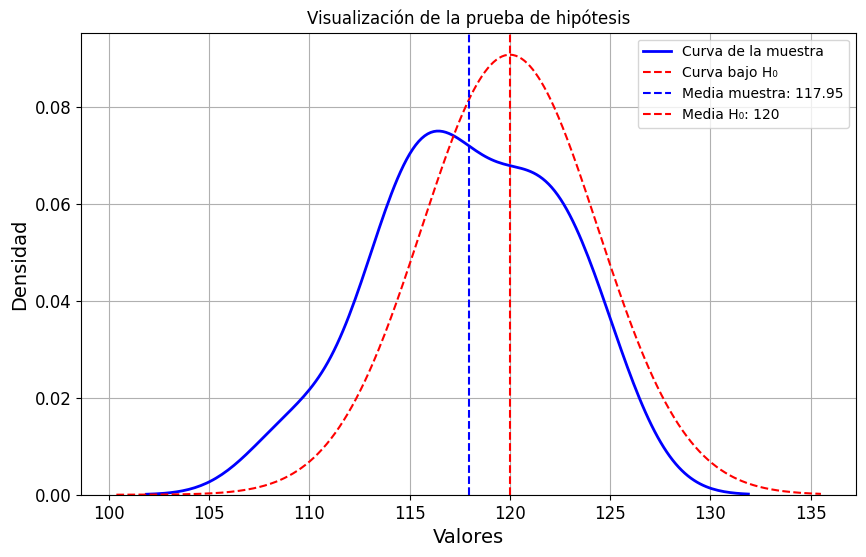

In [73]:
np.random.seed(1)
sample = np.random.normal(118, 4, 25)
run_hypothesis_test_C(sample, test_type='t', mu_h0=120)


[ANOVA]
Estadístico F: 0.3501
Valor p: 0.7056
Nivel de significancia α = 0.05
No hay evidencia de diferencias entre los grupos.


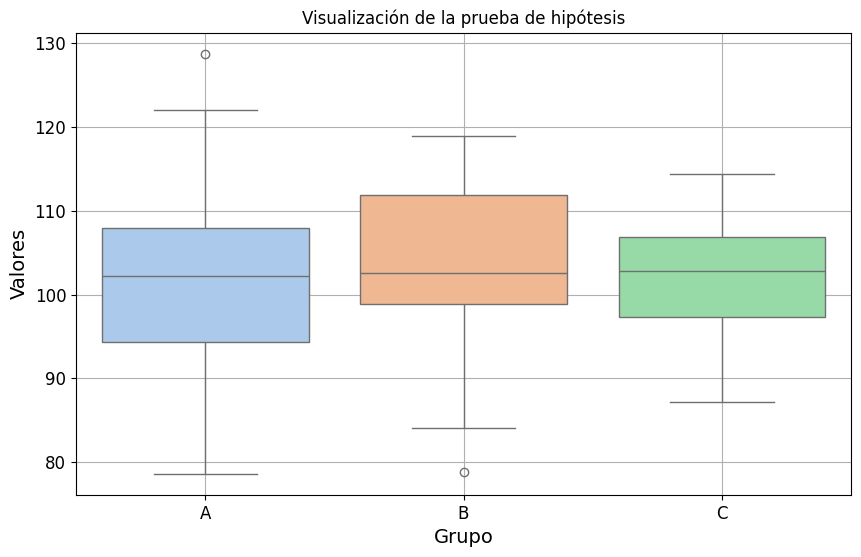

In [122]:
data = {
    "A": np.random.normal(100, 10, 30),
    "B": np.random.normal(105, 10, 30),
    "C": np.random.normal(98, 10, 30)
}
run_hypothesis_test_C(data, test_type='anova')


[Chi-Cuadrado]
Chi² = 0.6465, p = 0.4214, grados de libertad = 1
Nivel de significancia α = 0.05
No hay evidencia suficiente para rechazar H₀ (independencia).


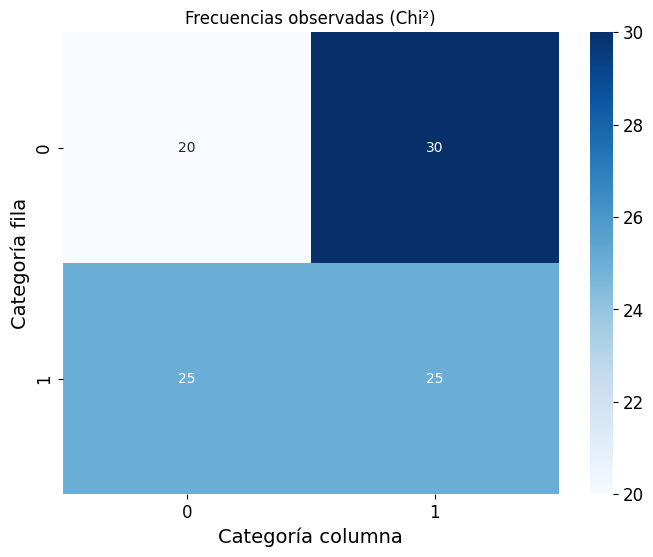

In [123]:
table = [[20, 30], [25, 25]]
run_hypothesis_test_C(table, test_type='chi2')

[T-Test]
Media de la muestra: 116.2547
Estadístico t: -4.9971
Valor p (una cola): 0.0000
Nivel de significancia α = 0.05
Se rechaza H₀: evidencia de que la media muestral < mu₀.


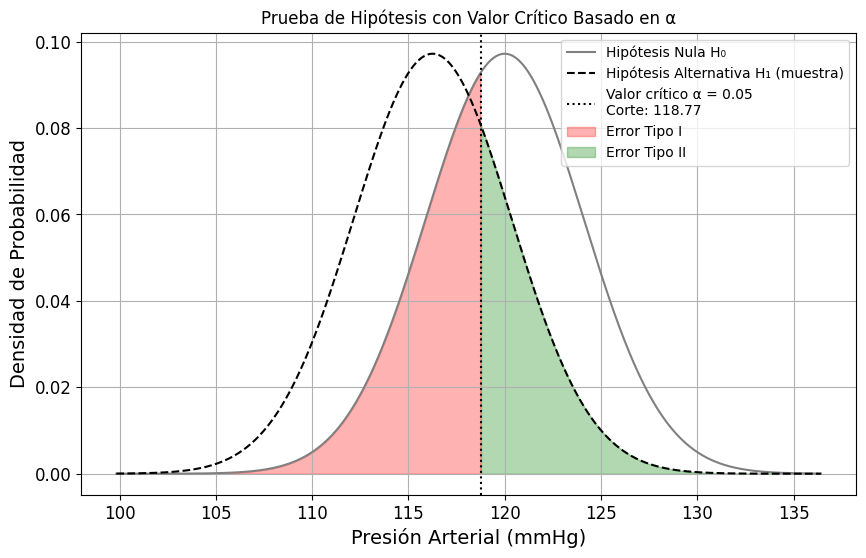

In [121]:
from scipy.stats import norm

def grafico_hipotesis_con_decision(muestra: list,
                                   mu_h0: float = 120,
                                   alpha: float = 0.05,
                                   desv_std_h0: float = None,
                                   color_h0: str = "gray",
                                   color_h1: str = "black",
                                   color_error_I: str = "red",
                                   color_error_II: str = "green",
                                   show: bool = True) -> None:
    """
    Grafica las curvas de H₀ y H₁ para una prueba de hipótesis y utiliza el valor crítico de Z (alpha)
    para definir la región de rechazo de H₀. La línea vertical representa el valor de corte basado en alpha.

    Parámetros
    ----------
    muestra : list
        Datos reales de la muestra (por ejemplo, presiones arteriales tras usar un medicamento).
    mu_h0 : float
        Valor de la media bajo la hipótesis nula.
    alpha : float
        Nivel de significancia (para prueba unilateral izquierda).
    desv_std_h0 : float
        Desviación estándar poblacional. Si no se especifica, se usa la de la muestra.
    color_h0 : str
        Color de la curva H₀.
    color_h1 : str
        Color de la curva H₁.
    color_error_I : str
        Color del área correspondiente a error tipo I.
    color_error_II : str
        Color del área correspondiente a error tipo II.
    show : bool
        Si True, muestra el gráfico.
    """
    muestra = np.array(muestra)
    mu_h1 = np.mean(muestra)
    std_h1 = np.std(muestra, ddof=1)

    if desv_std_h0 is None:
        desv_std_h0 = std_h1

    n = len(muestra)
    se_h0 = desv_std_h0 / np.sqrt(n)

    # Valor de corte basado en alpha (prueba unilateral izquierda)
    z_alpha = norm.ppf(alpha)
    cutoff = mu_h0 + z_alpha * se_h0  # menor que este valor => rechazo de H₀
    
    # Prueba t
    t_stat, p_two = ttest_1samp(muestra, popmean=mu_h0)
    p_one = p_two / 2

    # Resultados estadísticos
    print("[T-Test]")
    print(f"Media de la muestra: {mu_h1:.4f}")
    print(f"Estadístico t: {t_stat:.4f}")
    print(f"Valor p (una cola): {p_one:.4f}")
    print(f"Nivel de significancia α = {alpha}")
    if p_one < alpha and t_stat < 0:
        print("Se rechaza H₀: evidencia de que la media muestral < mu₀.")
    else:
        print("No hay evidencia suficiente para rechazar H₀.")
        
    # Rango del gráfico
    x_min = mu_h1 - 4 * std_h1
    x_max = mu_h0 + 4 * desv_std_h0
    x = np.linspace(x_min, x_max, 1000)

    # Densidades
    y_h0 = norm.pdf(x, mu_h0, desv_std_h0)
    y_h1 = norm.pdf(x, mu_h1, std_h1)

    # Gráfico
    plt.figure(figsize=(10, 6))
    plt.plot(x, y_h0, label="Hipótesis Nula H₀", color=color_h0)
    plt.plot(x, y_h1, label="Hipótesis Alternativa H₁ (muestra)", color=color_h1, linestyle='--')

    # Línea de decisión basada en alpha
    plt.axvline(cutoff, color='black', linestyle=':', label=f'Valor crítico α = {alpha:.2f}\nCorte: {cutoff:.2f}')

    # Rellenar Error Tipo I (bajo H₀, izquierda del corte)
    plt.fill_between(x, 0, y_h0, where=(x <= cutoff), color=color_error_I, alpha=0.3, label="Error Tipo I")

    # Rellenar Error Tipo II (bajo H₁, derecha del corte)
    plt.fill_between(x, 0, y_h1, where=(x > cutoff), color=color_error_II, alpha=0.3, label="Error Tipo II")

    plt.title("Prueba de Hipótesis con Valor Crítico Basado en α")
    plt.xlabel("Presión Arterial (mmHg)")
    plt.ylabel("Densidad de Probabilidad")
    plt.legend()
    plt.grid(True)

    if show:
        plt.show()

# Ejecutar con datos reales
datos_pacientes = [122.99, 114.05, 114.38, 112.20, 119.96, 107.29, 123.47, 113.45, 117.77, 115.50,
 122.34, 108.25, 115.21, 114.96, 121.03, 112.10, 115.81, 112.98, 116.66, 118.83,
 112.09, 121.07, 120.10, 118.50, 120.10, 113.76, 116.00, 112.75, 115.42, 118.62]


grafico_hipotesis_con_decision(muestra=datos_pacientes, mu_h0=120, alpha=0.05)


| Contexto                          | Valores comunes de α |
| --------------------------------- | -------------------- |
| Pruebas preliminares              | 0.10                 |
| Ciencias sociales, biológicas     | 0.05                 |
| Estudios médicos estrictos        | 0.01                 |
| Ensayos clínicos de vida o muerte | 0.001 o menos        |


In [3]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import random

# Título
st.title("Visualizador de Datos Aleatorios")

# Parámetros de generación
st.sidebar.header("Generación de datos")
num_filas = st.sidebar.slider("Número de filas", 100, 1000, 500)

# Generar datos aleatorios
def generar_datos(n):
    data = {
        "Ventas": [random.randint(100, 1000) for _ in range(n)],
        "Clientes": [random.randint(10, 100) for _ in range(n)],
        "Descuento": [random.uniform(0, 0.3) for _ in range(n)],
        "Mes": [random.choice(["Ene", "Feb", "Mar", "Abr"]) for _ in range(n)]
    }
    return pd.DataFrame(data)

df = generar_datos(num_filas)

# Mostrar tabla
st.subheader("Vista previa de los datos")
st.dataframe(df.head())

# Selección de columna numérica
columnas_numericas = df.select_dtypes(include='number').columns.tolist()
columna = st.selectbox("Selecciona una columna numérica para graficar", columnas_numericas)

# Graficar histograma
fig, ax = plt.subplots()
df[columna].plot.hist(bins=20, ax=ax)
ax.set_title(f"Histograma de {columna}")
ax.set_xlabel(columna)

st.pyplot(fig)


2025-07-01 15:13:09.540 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-01 15:13:09.543 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-01 15:13:09.543 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-01 15:13:09.545 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-01 15:13:09.545 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-01 15:13:09.546 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-01 15:13:09.547 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-01 15:13:09.547 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()